In [9]:
import os
from dotenv import load_dotenv
import pandas as pd
from sqlalchemy import create_engine
import numpy as np
import matplotlib.pyplot as plt

load_dotenv()

engine = create_engine(os.environ['DATABASE'])

In [10]:
pd.read_sql("SELECT MIN(orders.order_purchase_timestamp::timestamp), MAX(orders.order_purchase_timestamp::timestamp) FROM raw.orders", engine)

,min,max
0,2016-09-04 21:15:19,2018-10-17 17:30:18


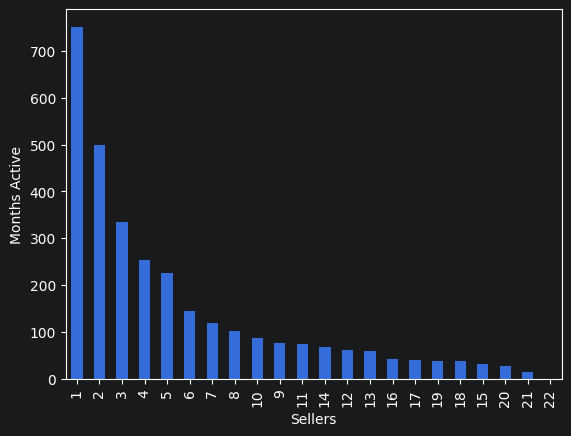

In [11]:
Query = """SELECT seller_id, COUNT(active_months) AS months_active
FROM (
    SELECT raw.order_items.seller_id, date_trunc('month', raw.orders.order_purchase_timestamp::timestamp) as active_month
    FROM raw.order_items
    JOIN raw.orders ON raw.order_items.order_id = raw.orders.order_id
    GROUP BY raw.order_items.seller_id, active_month
    ) AS active_months
GROUP BY seller_id
ORDER BY months_active DESC;"""


months_active = pd.read_sql(Query, engine)
months_active['months_active'].value_counts().plot(kind='bar')
plt.xlabel('Sellers')
plt.ylabel('Months Active')
plt.show()